# MKM411 — Computational Fluid Dynamics
## Lecture: Scientific Machine Learning for Fluid Dynamics
### Part 2 of 2 — Physics-Informed Neural Networks & the Broader Field
---
**Department of Mechanical & Aeronautical Engineering | University of Pretoria**  
*Prof K.J. Craig & Prof M. Bhamjee*

**Reference:** Raissi, M., Yazdani, A., & Karniadakis, G.E. (2020). Hidden fluid mechanics.
*Science*, 367(6481), 1026-1030. https://doi.org/10.1126/science.aaw4741


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

from lecture_utils import (UP_BLUE, UP_GOLD, ACCENT, SEED,
                            MinimalHeatPINN, NS_PINN,
                            plot_loss_comparison, plot_method_comparison,
                            plot_cylinder_fields, plot_vortex_street, 
                            plot_deeponet, plot_fno, plot_foundation_models, plot_gan,
                            plot_gnn, plot_rnn, plot_reservoir_computing, plot_sciml_landscape,
                            plot_method_comparison)

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")
print(f"Device Type : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"PyTorch : {torch.__version__}")


Device  : cuda
Device Type : NVIDIA RTX 2000 Ada Generation
PyTorch : 2.1.0+cu121


---
## 1. From ANN to PINN — The Key Idea

In Part 1 we saw that an ANN learns from data:

$$\mathcal{L}_{\text{ANN}} = \frac{1}{N}\sum_{i=1}^{N}\left(f_\theta(\mathbf{x}_i) - T_i^{\text{data}}\right)^2$$

A **Physics-Informed Neural Network** adds physics directly to the loss:

$$\mathcal{L}_{\text{PINN}} = \underbrace{\lambda_{\text{pde}}\,\mathcal{L}_{\text{pde}}}_{\text{PDE residual}} + \underbrace{\lambda_{\text{bc}}\,\mathcal{L}_{\text{bc}}}_{\text{boundary conditions}} + \underbrace{\lambda_{\text{ic}}\,\mathcal{L}_{\text{ic}}}_{\text{initial condition}}$$

The PDE residual is computed by **automatic differentiation** of the network
output with respect to its inputs — the same mechanism as backpropagation,
applied to inputs rather than weights.

**The network architecture is identical to the ANN. Only the loss function changes.**


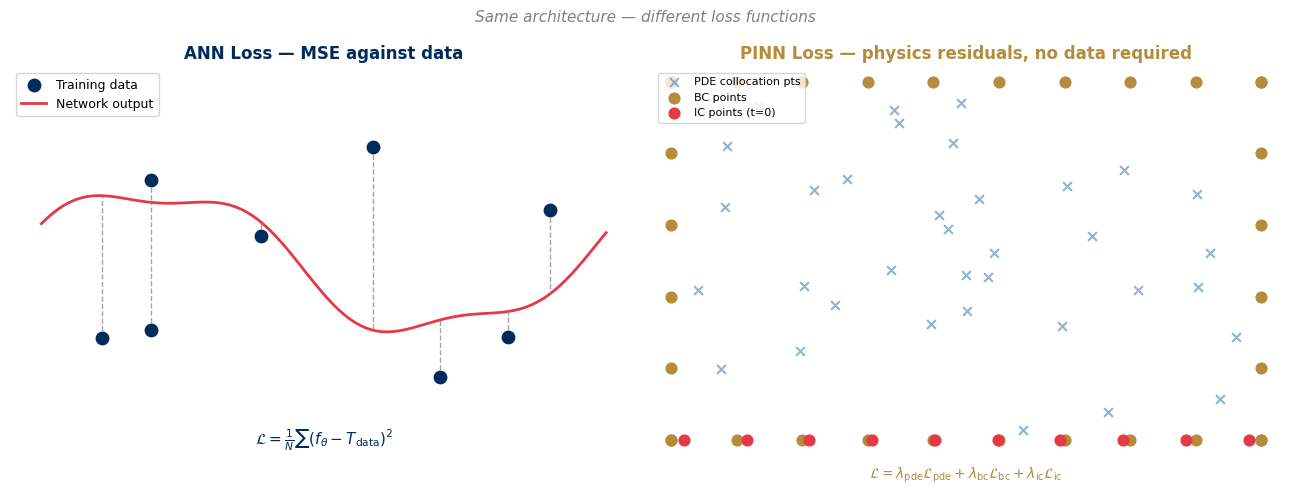

In [3]:
fig = plot_loss_comparison()
plt.show()


---
## 2. PINN for the Heat Equation — Bridge to Your Project

### Governing equation

$$\rho c_p \frac{\partial T}{\partial t} = k \left(\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2}\right)$$

### Chain rule for normalised coordinates

Since the network operates on $\hat{x} = x/L_x$:

$$\frac{\partial T}{\partial x} = \frac{\partial T}{\partial \hat{x}} \cdot \frac{1}{L_x}, \qquad \frac{\partial^2 T}{\partial x^2} = \frac{\partial^2 T}{\partial \hat{x}^2} \cdot \frac{1}{L_x^2}$$

Autograd computes $\partial T / \partial \hat{x}$ — the chain rule recovers the physical derivative.

### Two-phase optimiser (following Raissi 2019)
- **Phase 1 — Adam:** Fast global convergence
- **Phase 2 — L-BFGS:** Precise local convergence using curvature information


In [4]:
# Demonstrate autograd computing PDE derivatives through the network
net_demo = MinimalHeatPINN().to(device)

x_test = torch.linspace(0, 1, 20).unsqueeze(1).to(device)
t_test = torch.full_like(x_test, 0.5)
residual = net_demo.pde_residual(x_test, t_test, alpha=1e-4)

print("Autograd PDE residual — 1D heat equation (untrained network):")
print(f"  x in [{x_test.min().item():.1f}, {x_test.max().item():.1f}]")
print(f"  Residual: mean = {residual.abs().mean().item():.4f}  "
      f"max = {residual.abs().max().item():.4f}")
print()
print("After training, these residuals approach zero.")
print("That is what L_pde measures and minimises.")
print()
print("In your project: same framework, 2D, six inputs, all four BC/IC conditions.")


Autograd PDE residual — 1D heat equation (untrained network):
  x in [0.0, 1.0]
  Residual: mean = 0.4621  max = 0.4975

After training, these residuals approach zero.
That is what L_pde measures and minimises.

In your project: same framework, 2D, six inputs, all four BC/IC conditions.


---
## 3. Von Karman Vortex Street — Raissi et al. (2020)

### The physical problem
Flow past a circular cylinder at $Re = 100$ produces the Von Karman vortex street,
governed by the 2D incompressible Navier-Stokes equations:

$$\rho\left(\frac{\partial \mathbf{u}}{\partial t} + \mathbf{u} \cdot \nabla \mathbf{u}\right) = -\nabla p + \mu \nabla^2 \mathbf{u}, \qquad \nabla \cdot \mathbf{u} = 0$$

### What Raissi et al. (2020) did — Hidden Fluid Mechanics

They solved the **inverse problem**:

> *Given sparse, noisy measurements of a passive scalar concentration field $c(x,y,t)$,
> infer the full velocity $(u,v)$ and pressure $p$ fields.*

No velocity sensor. No pressure sensor. Just concentration — the kind obtained
from a dye experiment or particle image.

### Why this is remarkable
Classical methods require a well-posed forward problem. PINNs can infer
hidden fields from observable data by embedding multiple coupled PDEs in the loss.
This is a fundamentally different mode of scientific computing.

> **On inverse problems:** The same PINN framework that solves forward problems
> (given BCs, find the field) can be turned into an inverse solver (given observations,
> infer unknown fields and parameters). This is one of the most powerful and distinctive
> capabilities of PINNs — and an active area of research in fluid mechanics, geophysics,
> and biomedical engineering.


Dataset: 5,000 points | 200 time steps
Showing snapshot at t = 10.00 s


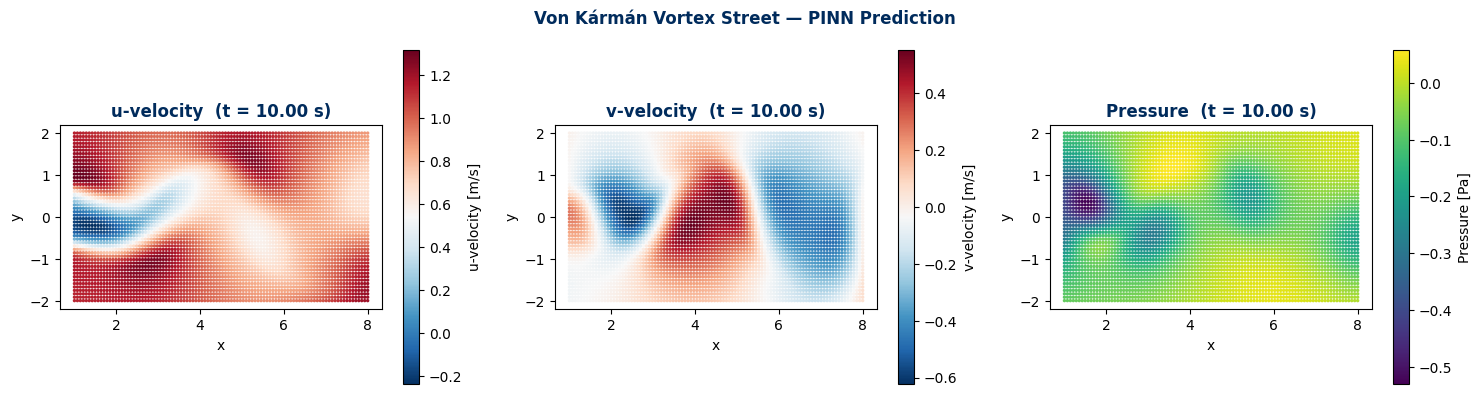

In [5]:
# Visualise the Von Karman vortex street
# Uses real Raissi dataset if available, otherwise synthetic illustration

DATA_PATH = "data/cylinder_nektar_wake.mat"

if os.path.exists(DATA_PATH):
    import scipy.io
    data   = scipy.io.loadmat(DATA_PATH)
    U_star = data['U_star']
    P_star = data['p_star']
    t_star = data['t'].flatten()
    X_star = data['X_star']

    t_idx = len(t_star) // 2
    x = X_star[:, 0]; y = X_star[:, 1]
    u = U_star[:, 0, t_idx]; v = U_star[:, 1, t_idx]
    p = P_star[:, t_idx]

    print(f"Dataset: {X_star.shape[0]:,} points | {len(t_star)} time steps")
    print(f"Showing snapshot at t = {t_star[t_idx]:.2f} s")
    fig = plot_cylinder_fields(x, y, u, v, p, t_val=t_star[t_idx])
    plt.show()
else:
    print("Dataset not found — showing synthetic illustration.")
    print("Download: https://github.com/maziarraissi/PINNs/tree/master/main/Data")
    fig = plot_vortex_street()
    plt.show()


### 3.1 The Navier-Stokes PINN Architecture

The PINN embeds four coupled PDEs in one composite loss:

$$\mathcal{L} = \mathcal{L}_{\text{data}}^c + \mathcal{L}_{\text{NS-x}} + \mathcal{L}_{\text{NS-y}} + \mathcal{L}_{\text{continuity}} + \mathcal{L}_{\text{advection-diffusion}}$$

**Network:** Input $(x,y,t)$ → Output $(u,v,p,c)$ — all four fields simultaneously  
**Architecture (Raissi 2020):** 9 hidden layers × 20 neurons, tanh, Xavier init  
**Training:** Adam (50,000 epochs) + L-BFGS (1,000 iterations)


In [6]:
# Show NS PINN architecture and residual structure
ns_net = NS_PINN(n_hidden=9, n_neurons=20).to(device)
print(f"NS PINN: 3 inputs → [20 x 9] → 4 outputs")
print(f"Parameters: {ns_net.n_params():,}")
print()
print("Four PDE residuals computed via autograd:")
print("  f_u   = rho(u_t + u*u_x + v*u_y) + p_x - mu*(u_xx + u_yy)  [x-momentum]")
print("  f_v   = rho(v_t + u*v_x + v*v_y) + p_y - mu*(v_xx + v_yy)  [y-momentum]")
print("  f_div = u_x + v_y                                             [continuity]")
print("  f_adv = c_t + u*c_x + v*c_y - kappa*(c_xx + c_yy)           [advection-diffusion]")
print()

# Quick residual demo (untrained)
x_t = torch.tensor([[1.0], [2.0]], dtype=torch.float32).to(device)
y_t = torch.tensor([[0.0], [0.5]], dtype=torch.float32).to(device)
t_t = torch.tensor([[1.0], [1.0]], dtype=torch.float32).to(device)
f_u, f_v, f_div, f_adv = ns_net.ns_residuals(x_t, y_t, t_t)
print("Residuals at 2 test points (untrained — should be non-zero):")
print(f"  f_u  : {f_u.detach().cpu().numpy().flatten().round(3)}")
print(f"  f_div: {f_div.detach().cpu().numpy().flatten().round(3)}")
print()
print("After training: all four residuals approach zero across all collocation points.")


NS PINN: 3 inputs → [20 x 9] → 4 outputs
Parameters: 3,524

Four PDE residuals computed via autograd:
  f_u   = rho(u_t + u*u_x + v*u_y) + p_x - mu*(u_xx + u_yy)  [x-momentum]
  f_v   = rho(v_t + u*v_x + v*v_y) + p_y - mu*(v_xx + v_yy)  [y-momentum]
  f_div = u_x + v_y                                             [continuity]
  f_adv = c_t + u*c_x + v*c_y - kappa*(c_xx + c_yy)           [advection-diffusion]

Residuals at 2 test points (untrained — should be non-zero):
  f_u  : [-0.098 -0.046]
  f_div: [-0.09  -0.097]

After training: all four residuals approach zero across all collocation points.


### 3.2 Pre-trained Results

Training the NS PINN requires ~50,000 Adam + 1,000 L-BFGS iterations (~2-3 hours on A2000).
The pre-trained model is loaded below.


Pre-trained NS PINN loaded.


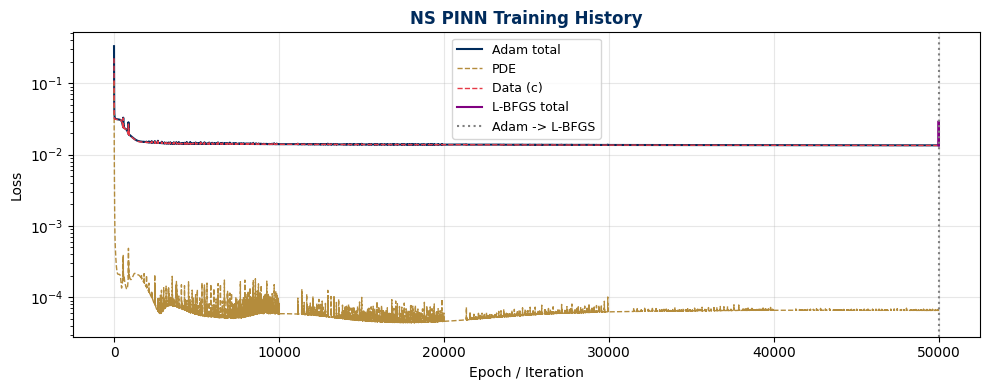

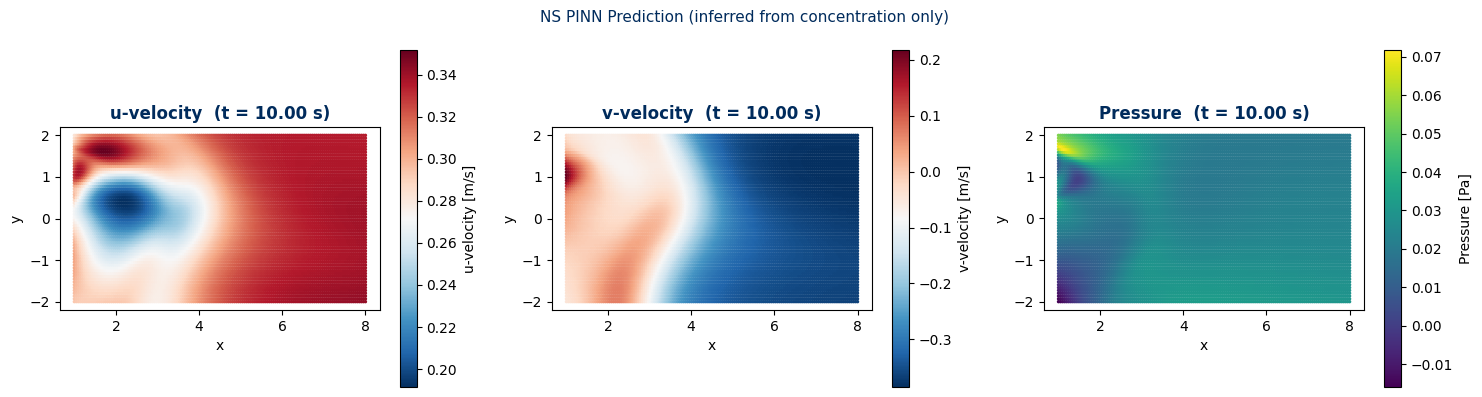

In [9]:
MODEL_PATH = "data/ns_pinn_pretrained.pt"

if os.path.exists(MODEL_PATH):
    ns_net.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    ns_net.eval()
    print("Pre-trained NS PINN loaded.")

    # Load loss history if available
    LOSS_PATH = "data/ns_pinn_loss_history.npz"
    if os.path.exists(LOSS_PATH):
        hist = np.load(LOSS_PATH)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.semilogy(hist['adam_total'], color=UP_BLUE, lw=1.5, label='Adam total')
        ax.semilogy(hist['adam_pde'],   color=UP_GOLD, lw=1.0, ls='--', label='PDE')
        ax.semilogy(hist['adam_data'],  color=ACCENT,  lw=1.0, ls='--', label='Data (c)')
        n_adam = len(hist['adam_total'])
        lbfgs_x = np.arange(n_adam, n_adam + len(hist['lbfgs_total']))
        ax.semilogy(lbfgs_x, hist['lbfgs_total'], color='purple', lw=1.5,
                    label='L-BFGS total')
        ax.axvline(n_adam, color='gray', ls=':', lw=1.5, label='Adam -> L-BFGS')
        ax.set_xlabel('Epoch / Iteration'); ax.set_ylabel('Loss')
        ax.set_title('NS PINN Training History', color=UP_BLUE, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    # Predict on a grid
    if os.path.exists(DATA_PATH):
        import scipy.io
        data   = scipy.io.loadmat(DATA_PATH)
        X_star = data['X_star']
        t_star = data['t'].flatten()
        t_eval = t_star[len(t_star)//2]

        x_arr = np.linspace(X_star[:,0].min(), X_star[:,0].max(), 150)
        y_arr = np.linspace(X_star[:,1].min(), X_star[:,1].max(), 60)
        Xg, Yg = np.meshgrid(x_arr, y_arr)

        def to_t(a):
            return torch.tensor(a.flatten(), dtype=torch.float32).unsqueeze(1).to(device)

        with torch.no_grad():
            u_p, v_p, p_p, _ = ns_net(to_t(Xg), to_t(Yg),
                                        torch.full((Xg.size,1), t_eval).to(device))

        fig = plot_cylinder_fields(
            Xg.flatten(), Yg.flatten(),
            u_p.cpu().numpy().flatten(),
            v_p.cpu().numpy().flatten(),
            p_p.cpu().numpy().flatten(),
            t_val=t_eval)
        plt.suptitle('NS PINN Prediction (inferred from concentration only)',
                     fontsize=11, color=UP_BLUE)
        plt.show()

else:
    print("Pre-trained model not found at data/ns_pinn_pretrained.pt")
    print()
    print("To generate before the lecture, run on Mjolnir:")
    print("  python lecture_utils/train_ns_pinn.py")
    print()
    print("Estimated training time: 2-3 hours on RTX A2000")


In [8]:
!python lecture_utils/train_ns_pinn.py

Device  : cuda
PyTorch : 2.1.0+cu121

Loading dataset: /srv/shared/pytorch/mkm411-sciml-lectures/lecture_utils/../data/cylinder_nektar_wake.mat
  Spatial points : 5,000
  Time steps     : 200

Training data:
  Concentration observations : 5,000
  PDE collocation points     : 50,000

Model parameters: 3,524

Phase 1 — Adam | 50,000 epochs | lr=0.001
------------------------------------------------------------
  epoch   1000 | total=1.8416e-02 | pde=1.7723e-04 | data=1.8239e-02 | 93 s
  epoch   2000 | total=1.4952e-02 | pde=1.3493e-04 | data=1.4817e-02 | 186 s
  epoch   3000 | total=1.4449e-02 | pde=6.6680e-05 | data=1.4383e-02 | 280 s
  epoch   4000 | total=1.4300e-02 | pde=7.0966e-05 | data=1.4229e-02 | 375 s
  epoch   5000 | total=1.4240e-02 | pde=5.8207e-05 | data=1.4182e-02 | 468 s
  epoch   6000 | total=1.4200e-02 | pde=5.3548e-05 | data=1.4146e-02 | 562 s
  epoch   7000 | total=1.4159e-02 | pde=5.0537e-05 | data=1.4108e-02 | 656 s
  epoch   8000 | total=1.4179e-02 | pde=6.3759e-05

---
## 4. Strengths, Failure Modes, and Open Challenges

### Strengths
- **Mesh-free** — no spatial discretisation required
- **Inverse problems** — infer unknown fields from observable data
- **Parametric** — one network, many parameter values
- **Continuous solution** — query at any point, not just grid nodes

### Failure modes

| Issue | Cause | Mitigation |
|-------|-------|-----------|
| **Trivial solution** | PDE loss zero for constant output | Higher $\lambda_{\text{bc}}$, $\lambda_{\text{ic}}$; output normalisation |
| **Training instability** | Competing loss terms | Normalise inputs/outputs; adaptive weights |
| **Spectral bias** | Networks learn low frequencies first | Fourier feature embeddings |
| **Collocation overfitting** | Fixed random points memorised | Periodic resampling |
| **Slow convergence** | Adam alone insufficient | Two-phase: Adam + L-BFGS |

### Open challenges
- Complex geometries and high Reynolds number flows
- Uncertainty quantification
- Computational cost vs classical methods
- Convergence theory still developing


---
## 5. The SciML Landscape — A Panorama

**Scientific Machine Learning** embeds physical knowledge into the learning process.
Below is a tour of the main approaches, each with its own architectural idea
and niche in the fluid dynamics workflow.


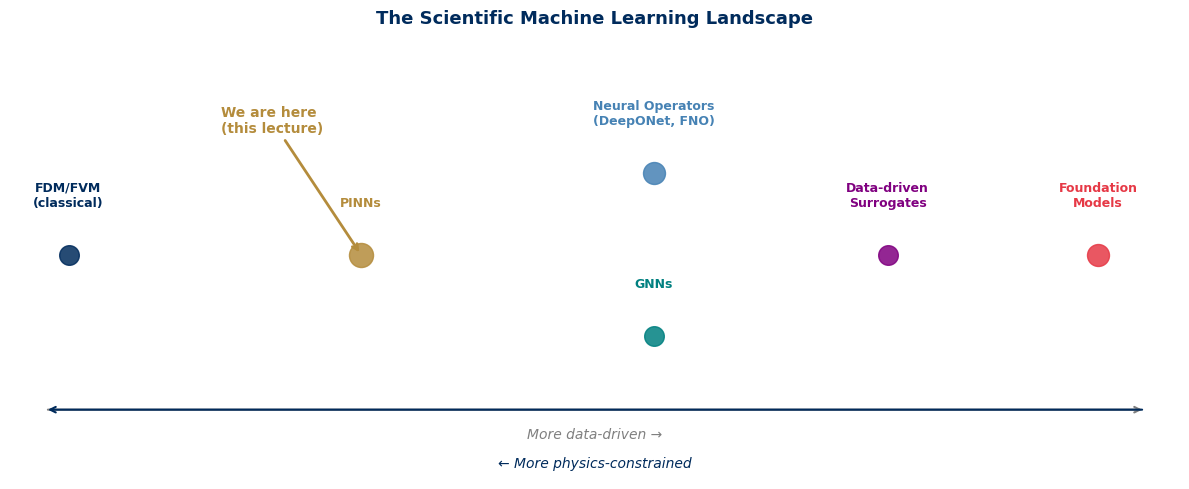

In [12]:
fig = plot_sciml_landscape(highlight_pinn=True)
plt.show()


### 5.1 DeepONet — Learning Operators Between Function Spaces

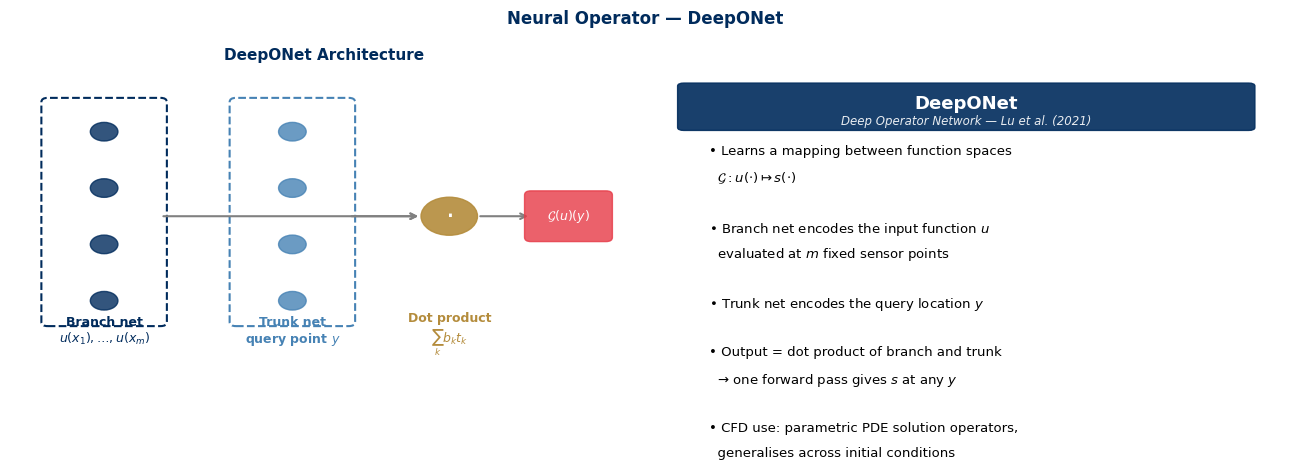

In [13]:
fig = plot_deeponet()
plt.show()


### 5.2 Fourier Neural Operator (FNO) — Convolution in Spectral Space

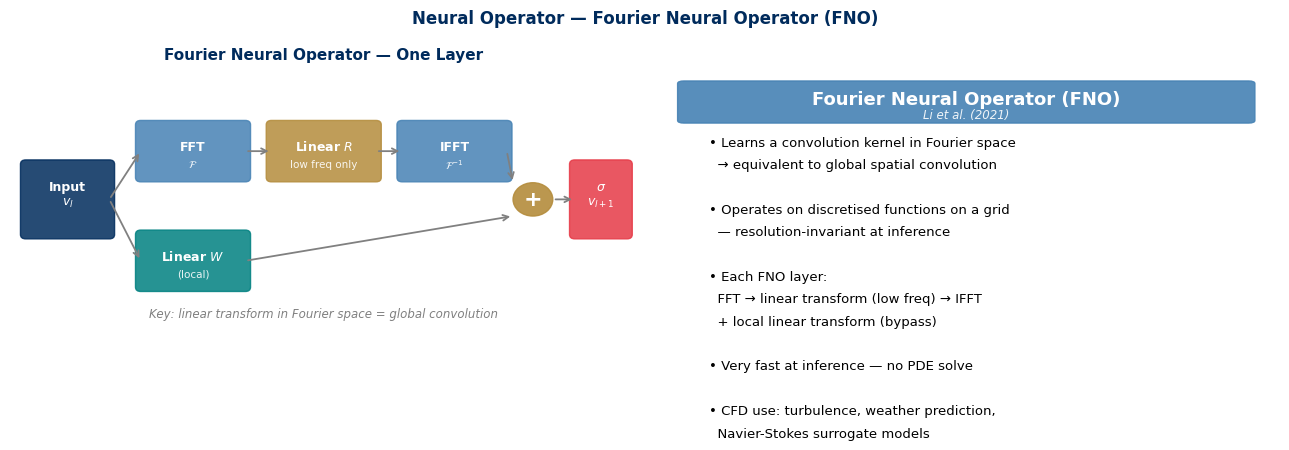

In [14]:
fig = plot_fno()
plt.show()


### 5.3 Graph Neural Networks (GNNs) — Learning on Meshes

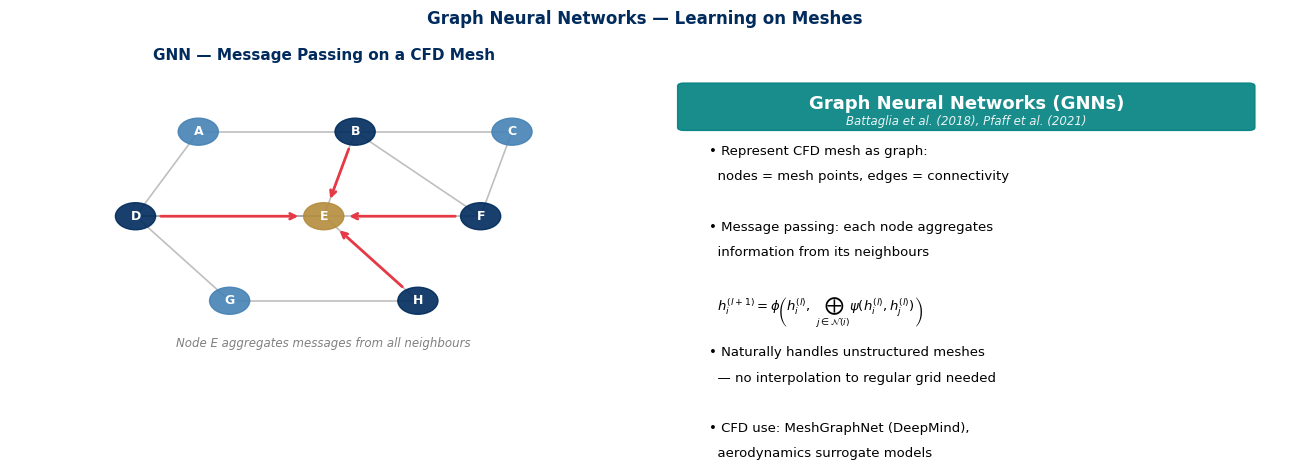

In [15]:
fig = plot_gnn()
plt.show()


### 5.4 Generative Adversarial Networks (GANs) — Learning Distributions

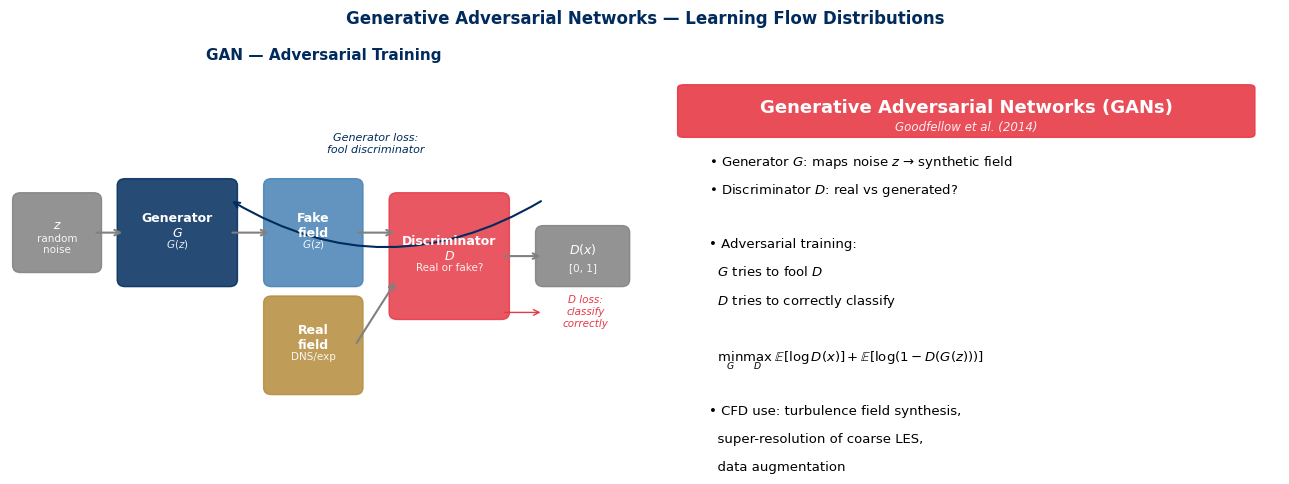

In [16]:
fig = plot_gan()
plt.show()


### 5.5 Recurrent Neural Networks (RNNs / LSTMs) — Temporal Memory

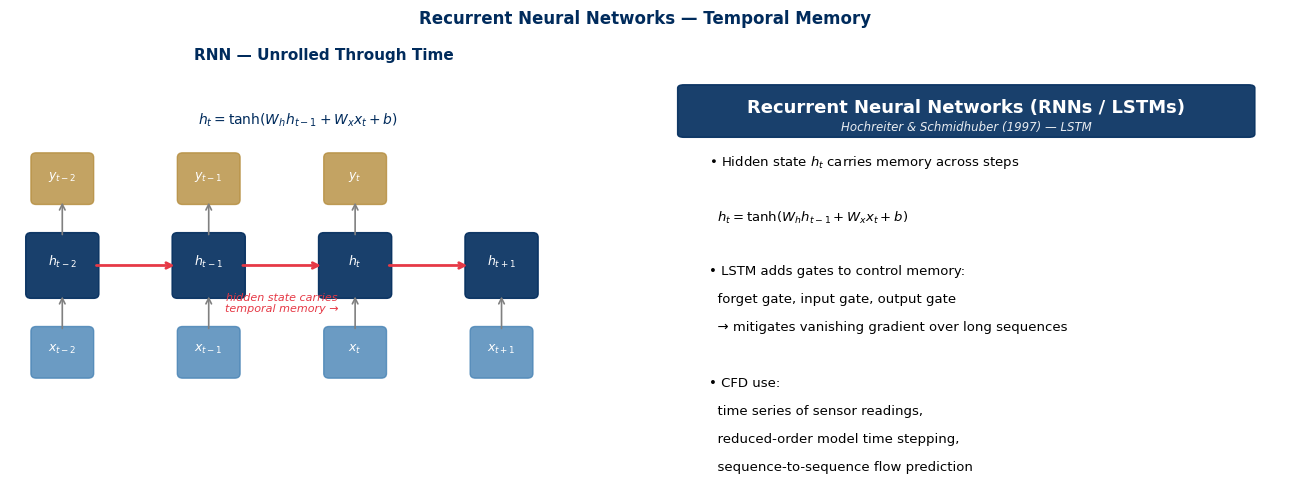

In [17]:
fig = plot_rnn()
plt.show()


### 5.6 Reservoir Computing — Fixed Dynamics, Trained Readout

Reservoir Computing takes a fundamentally different approach to the other methods.
The reservoir is a fixed, randomly connected recurrent network — it is never trained.
Only the output layer is learned, via simple linear regression.

The physics interpretation is elegant: the reservoir acts as a **nonlinear dynamical
projection** of the input time series into a high-dimensional state space. The output
layer then reads off the relevant coordinates. Echo State Networks (ESNs) are the most
common implementation.

This makes RC extremely fast to train compared to deep RNNs, while retaining good
performance on chaotic and nonlinear dynamical systems — exactly the regime of
turbulent flows.


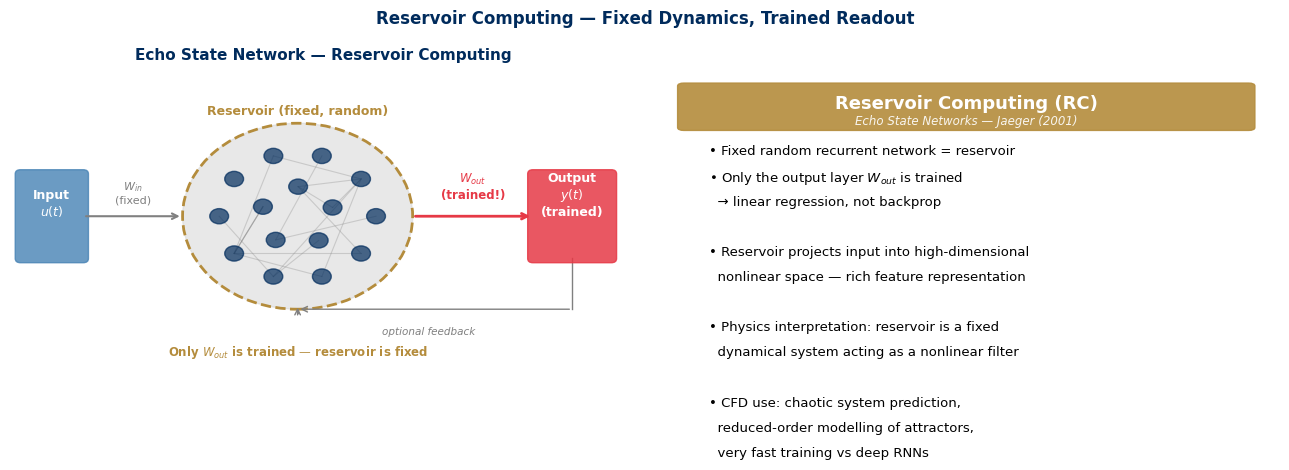

In [18]:
fig = plot_reservoir_computing()
plt.show()


### 5.7 Foundation Models — Pre-trained at Scale

The most recent frontier. Large transformer-based models pre-trained on massive
simulation and observational datasets, then fine-tuned for specific tasks.
Analogous to how GPT is pre-trained on text then fine-tuned per application.

Currently the most prominent examples are in weather and climate modelling,
where training data is abundant and the governing equations are well-established.
Application to general CFD is an active area of research.


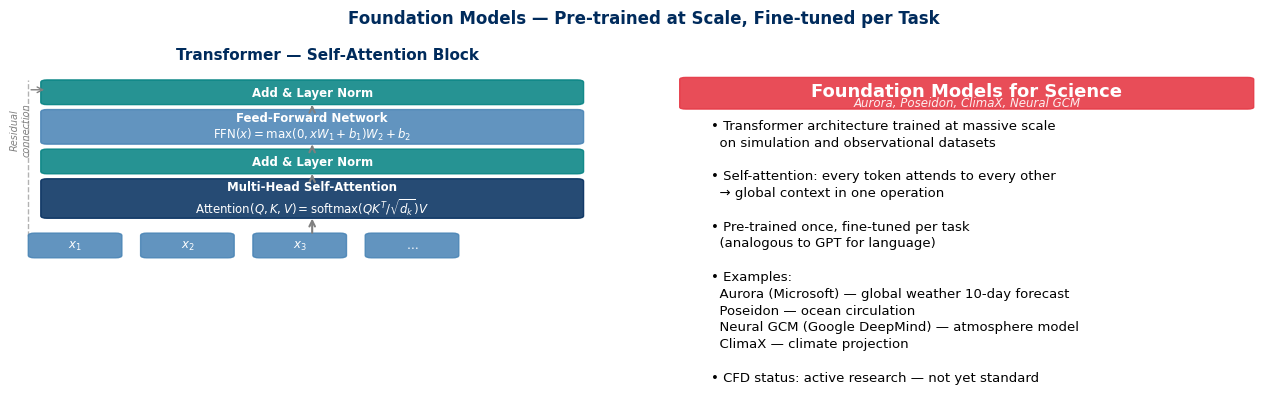

In [19]:
fig = plot_foundation_models()
plt.show()


### Summary — Method Comparison

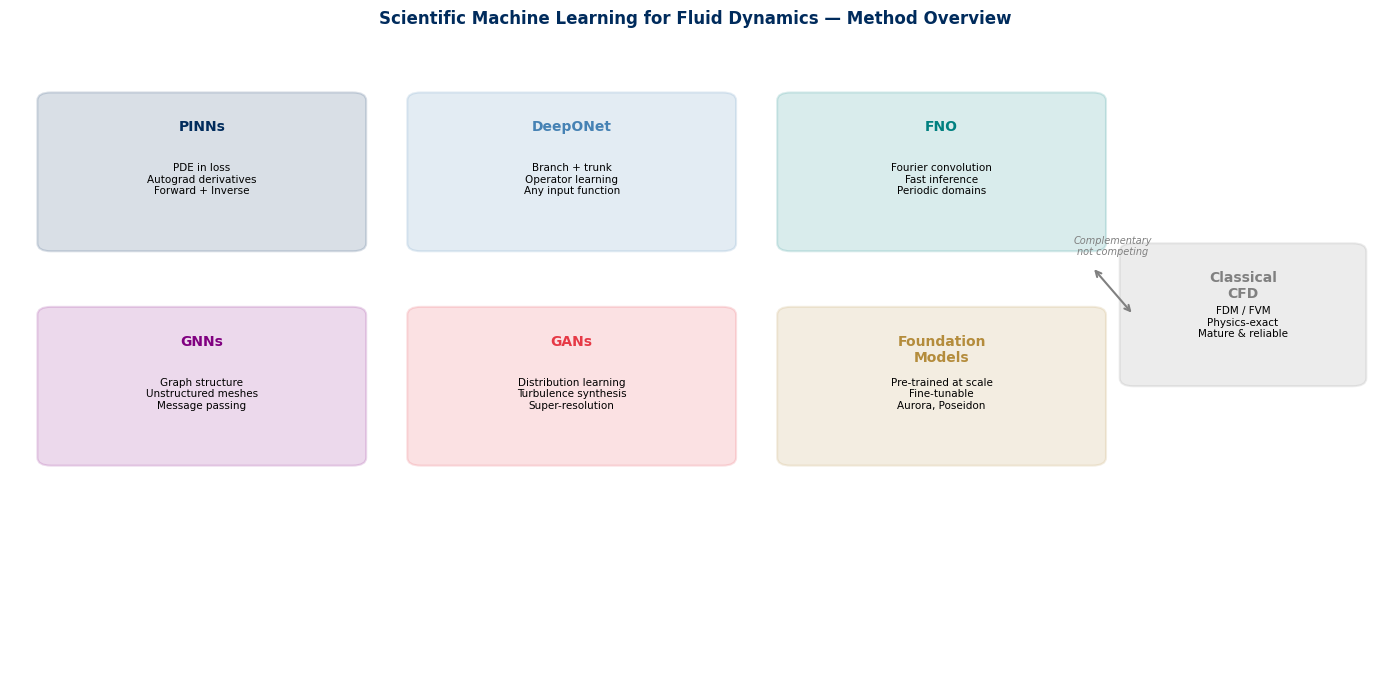

In [20]:
fig = plot_method_comparison()
plt.show()


---
## Summary — Part 2

| Concept | Key takeaway |
|---------|-------------|
| **PINN idea** | Embed PDE as a loss term — no data needed for physics |
| **Autograd** | Same mechanism as backpropagation, applied to inputs |
| **NS PINN** | Four coupled PDEs in one loss — infers hidden fields |
| **Inverse problems** | PINNs can infer unknowns from sparse observations |
| **Failure modes** | Trivial solutions, spectral bias, slow convergence — active research |
| **SciML landscape** | Seven methods from PINNs to Foundation Models — each with a niche |

### Connection to your project
The project PINN uses the same framework — autograd derivatives, composite loss,
Adam + L-BFGS — applied to the 2D heat equation with six parametric inputs.
The NS equations are more complex, but the structure is identical.

---
*End of MKM411 SciML Lecture | Department of Mechanical & Aeronautical Engineering*
